# Laboratory Exercise 7: Image Perception Model Replacement

**Name:** Lorenzo Bela, Robert Callorina, Kean Guzon

**Section:** 58036

**Date:** 04/15/2026

**Dataset name:** Lab04 EDA Bias Dataset (bottled water, canned goods, combo, Noodles, Rice)

In [1]:
# Cell 1 - Install and import dependencies
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
import timm
from ultralytics.nn.tasks import DetectionModel

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix

NAME = "Lorenzo Bela, Robert Callorina, Kean Guzon"
SECTION = "58036"
DATE = "04/15/2026"
DATASET_NAME = "Lab04 EDA Bias Dataset"

print(f"Name: {NAME}")
print(f"Section: {SECTION}")
print(f"Date: {DATE}")
print(f"Dataset name: {DATASET_NAME}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Name: Lorenzo Bela, Robert Callorina, Kean Guzon
Section: 58036
Date: 04/15/2026
Dataset name: Lab04 EDA Bias Dataset
PyTorch: 2.11.0+cpu
CUDA available: False
Device: cpu


## Part B) Load and Prepare Dataset

In [2]:
# Cell 2 - Transforms
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-3

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebook":
    NOTEBOOK_DIR = Path("ml-perception-labs/lab07_model_replacement/notebook").resolve()

LAB07_DIR = NOTEBOOK_DIR.parent
DATA_DIR = LAB07_DIR / "data" / "raw"
if not DATA_DIR.exists():
    DATA_DIR = Path("ml-perception-labs/lab06_cnn/data/raw").resolve()

FIGURES_DIR = LAB07_DIR / "outputs" / "figures"
TABLES_DIR = LAB07_DIR / "outputs" / "tables"
LOGS_DIR = LAB07_DIR / "outputs" / "logs"

for p in [FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Lab07 dir: {LAB07_DIR}")
print(f"Data dir: {DATA_DIR}")


Lab07 dir: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab07_model_replacement
Data dir: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab07_model_replacement\data\raw


In [3]:
# Cell 3 - Load and split dataset
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

full_dataset_aug = ImageFolder(root=DATA_DIR, transform=train_transform)
CLASS_NAMES = full_dataset_aug.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total images: {len(full_dataset_aug)}")

n_total = len(full_dataset_aug)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

indices = torch.randperm(n_total, generator=torch.Generator().manual_seed(SEED)).tolist()
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

train_set = Subset(full_dataset_aug, train_idx)

full_dataset_eval = ImageFolder(root=DATA_DIR, transform=eval_transform)
val_set = Subset(full_dataset_eval, val_idx)
test_set = Subset(full_dataset_eval, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


Classes (5): ['Noodles', 'Rice', 'bottled water', 'canned goods', 'combo']
Total images: 250
Train: 175 | Val: 37 | Test: 38


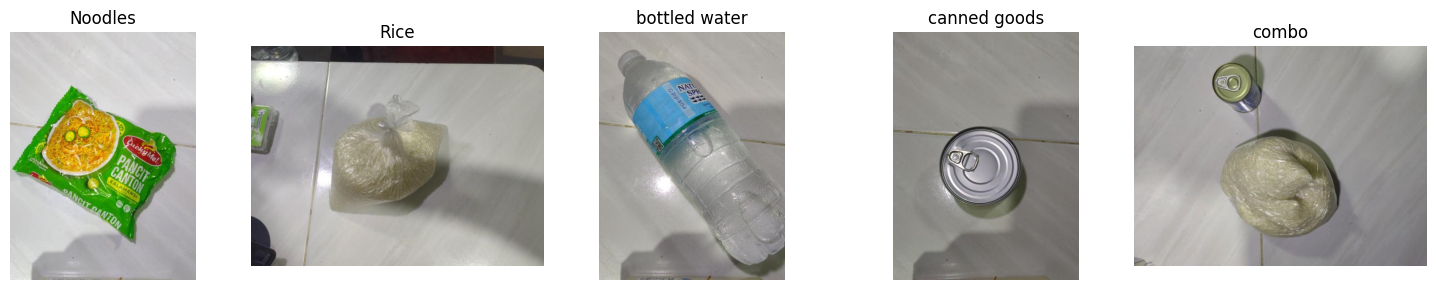

Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab07_model_replacement\outputs\figures\lab07_dataset_samples.png


In [4]:
# Cell 3b - Display example images per class and save figure
raw_dataset = ImageFolder(root=DATA_DIR)

sample_paths = {}
for path, label in raw_dataset.samples:
    cls = raw_dataset.classes[label]
    if cls not in sample_paths:
        sample_paths[cls] = path

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(3 * len(CLASS_NAMES), 3))
if len(CLASS_NAMES) == 1:
    axes = [axes]

for ax, cls in zip(axes, CLASS_NAMES):
    img = Image.open(sample_paths[cls]).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_dataset_samples.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab07_dataset_samples.png")


## Part C) Define CNN Architectures

In [5]:
# Cell 4 - Model A: EfficientDetLite0
class EfficientDetLite0Classifier(nn.Module):
    """EfficientDetLite0-style lightweight backbone classifier."""

    def __init__(self, num_classes):
        super().__init__()
        self.net = timm.create_model("efficientnet_lite0", pretrained=False, num_classes=num_classes)

    def forward(self, x):
        return self.net(x)


model_a = EfficientDetLite0Classifier(NUM_CLASSES).to(DEVICE)
params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"EfficientDetLite0 | Parameters: {params_a:,}")


EfficientDetLite0 | Parameters: 3,377,413


In [6]:
# Cell 5 - Model B: MobileNetV2
class MobileNetV2Classifier(nn.Module):
    """MobileNetV2 with custom output head for the lab classes."""

    def __init__(self, num_classes):
        super().__init__()
        self.net = mobilenet_v2(weights=None)
        in_features = self.net.classifier[1].in_features
        self.net.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.net(x)


model_b = MobileNetV2Classifier(NUM_CLASSES).to(DEVICE)
params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"MobileNetV2 | Parameters: {params_b:,}")


MobileNetV2 | Parameters: 2,230,277


In [7]:
# Cell 6 - Model C: YOLOv8Nano
class YOLODetectionClassifier(nn.Module):
    """Converts YOLO detection score maps into image-level logits."""

    def __init__(self, cfg_path, num_classes):
        super().__init__()
        self.detector = DetectionModel(cfg_path, nc=num_classes, verbose=False)

    @staticmethod
    def _extract_scores(raw_output):
        if isinstance(raw_output, dict):
            if "scores" in raw_output:
                return raw_output["scores"]
            if "one2one" in raw_output and "scores" in raw_output["one2one"]:
                return raw_output["one2one"]["scores"]

        if isinstance(raw_output, tuple) and len(raw_output) > 1 and isinstance(raw_output[1], dict):
            meta = raw_output[1]
            if "scores" in meta:
                return meta["scores"]
            if "one2one" in meta and "scores" in meta["one2one"]:
                return meta["one2one"]["scores"]

        raise RuntimeError("Unable to extract YOLO score tensor.")

    def forward(self, x):
        raw_output = self.detector(x)
        scores = self._extract_scores(raw_output)  # [B, C, N]
        return scores.amax(dim=2)  # [B, C]


model_c = YOLODetectionClassifier("yolov8n.yaml", NUM_CLASSES).to(DEVICE)
params_c = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
print(f"YOLOv8Nano | Parameters: {params_c:,}")


Overriding model.yaml nc=80 with nc=5
YOLOv8Nano | Parameters: 3,011,807


In [8]:
# Cell 6b - Model D: YOLOv10Nano
model_d = YOLODetectionClassifier("yolov10n.yaml", NUM_CLASSES).to(DEVICE)
params_d = sum(p.numel() for p in model_d.parameters() if p.requires_grad)
print(f"YOLOv10Nano | Parameters: {params_d:,}")


Overriding model.yaml nc=80 with nc=5
YOLOv10Nano | Parameters: 2,708,974


## Part D) Define Loss Function and Optimizer

In [9]:
# Cell 7 - Loss, optimizer, scheduler factory functions
def make_optimizer(model):
    return optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)


def make_scheduler(optimizer):
    return optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


criterion = nn.CrossEntropyLoss()
print("Loss: CrossEntropyLoss")
print("Optimizer: Adam (lr=1e-3, weight_decay=1e-4)")
print("Scheduler: StepLR (step=10, gamma=0.5)")


Loss: CrossEntropyLoss
Optimizer: Adam (lr=1e-3, weight_decay=1e-4)
Scheduler: StepLR (step=10, gamma=0.5)


## Part E) Train All Four Models

In [10]:
# Cell 8 - Reusable training loop
def train_model(model, train_loader, val_loader, num_epochs, model_name):
    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            correct += out.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)

        train_loss = run_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out, labels).item() * imgs.size(0)
                v_correct += out.max(1)[1].eq(labels).sum().item()
                v_total += labels.size(0)

        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"[{model_name}] Ep {epoch:3d} | "
                f"TrainLoss={train_loss:.4f} Acc={train_acc:.4f} | "
                f"ValLoss={val_loss:.4f} Acc={val_acc:.4f}"
            )

    if best_weights is not None:
        model.load_state_dict(best_weights)

    print(f"Best Val Acc ({model_name}): {best_val_acc:.4f}")
    return history


In [11]:
# Cell 9 - Train all four models
print("=" * 55)
print("Training Model A - EfficientDetLite0")
history_a = train_model(model_a, train_loader, val_loader, NUM_EPOCHS, "EfficientDetLite0")

print("\n" + "=" * 55)
print("Training Model B - MobileNetV2")
history_b = train_model(model_b, train_loader, val_loader, NUM_EPOCHS, "MobileNetV2")

print("\n" + "=" * 55)
print("Training Model C - YOLOv8Nano")
history_c = train_model(model_c, train_loader, val_loader, NUM_EPOCHS, "YOLOv8Nano")

print("\n" + "=" * 55)
print("Training Model D - YOLOv10Nano")
history_d = train_model(model_d, train_loader, val_loader, NUM_EPOCHS, "YOLOv10Nano")


Training Model A - EfficientDetLite0
[EfficientDetLite0] Ep   1 | TrainLoss=4.0879 Acc=0.3143 | ValLoss=4.5512 Acc=0.2432
[EfficientDetLite0] Ep   5 | TrainLoss=3.7256 Acc=0.2914 | ValLoss=3.2099 Acc=0.3243
[EfficientDetLite0] Ep  10 | TrainLoss=2.1572 Acc=0.3657 | ValLoss=2.6629 Acc=0.3243
[EfficientDetLite0] Ep  15 | TrainLoss=1.4047 Acc=0.4457 | ValLoss=1.4438 Acc=0.4324
[EfficientDetLite0] Ep  20 | TrainLoss=1.3070 Acc=0.4914 | ValLoss=1.5248 Acc=0.4054
[EfficientDetLite0] Ep  25 | TrainLoss=1.1113 Acc=0.5429 | ValLoss=1.3948 Acc=0.4324
[EfficientDetLite0] Ep  30 | TrainLoss=1.1581 Acc=0.5600 | ValLoss=1.3565 Acc=0.4324
Best Val Acc (EfficientDetLite0): 0.4595

Training Model B - MobileNetV2
[MobileNetV2] Ep   1 | TrainLoss=1.6668 Acc=0.1714 | ValLoss=1.6185 Acc=0.2432
[MobileNetV2] Ep   5 | TrainLoss=1.4248 Acc=0.4057 | ValLoss=1.6706 Acc=0.2432
[MobileNetV2] Ep  10 | TrainLoss=1.1022 Acc=0.5429 | ValLoss=1.7892 Acc=0.1892
[MobileNetV2] Ep  15 | TrainLoss=0.8402 Acc=0.7200 | ValLo

## Part F) Evaluate Model Performance

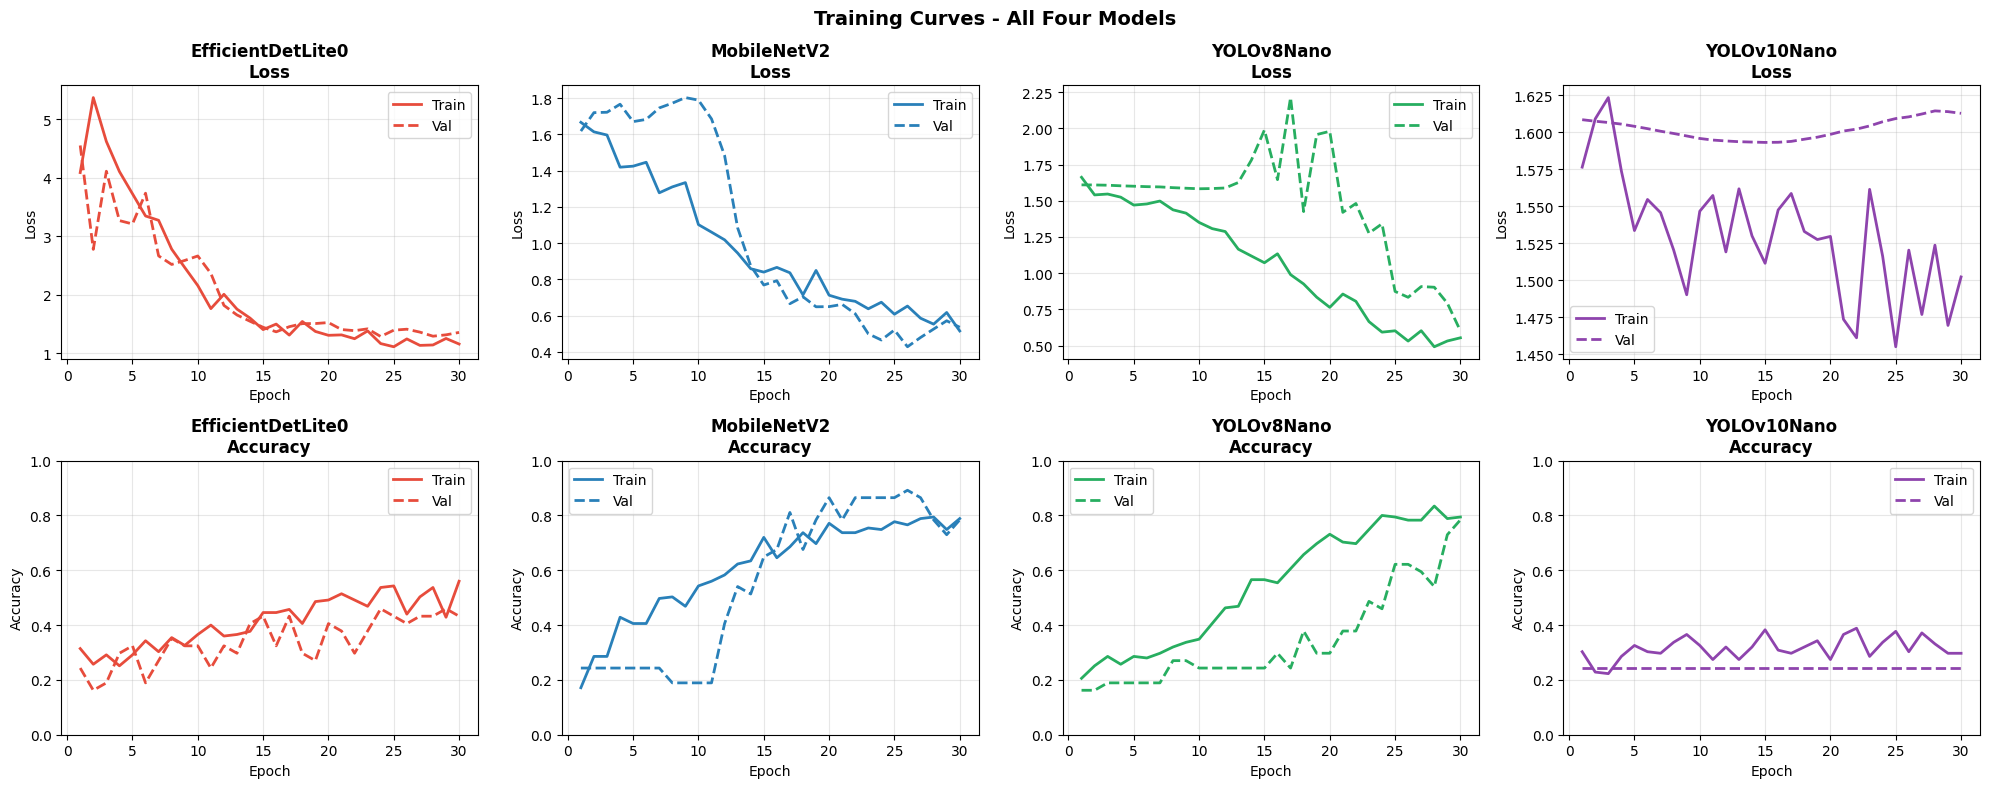

Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab07_model_replacement\outputs\figures\lab07_training_curves.png


In [12]:
# Cell 10 - Training curves (loss and accuracy)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
info = [
    (history_a, "EfficientDetLite0", "#E74C3C"),
    (history_b, "MobileNetV2", "#2980B9"),
    (history_c, "YOLOv8Nano", "#27AE60"),
    (history_d, "YOLOv10Nano", "#8E44AD"),
]
epochs = range(1, NUM_EPOCHS + 1)

for col, (hist, name, color) in enumerate(info):
    for row, (key_tr, key_vl, ylabel) in enumerate([
        ("train_loss", "val_loss", "Loss"),
        ("train_acc", "val_acc", "Accuracy"),
    ]):
        ax = axes[row, col]
        ax.plot(epochs, hist[key_tr], label="Train", color=color, lw=2)
        ax.plot(epochs, hist[key_vl], label="Val", color=color, lw=2, ls="--")
        ax.set_title(f"{name}\n{ylabel}", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        if ylabel == "Accuracy":
            ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(alpha=0.3)

plt.suptitle("Training Curves - All Four Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_training_curves.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab07_training_curves.png")


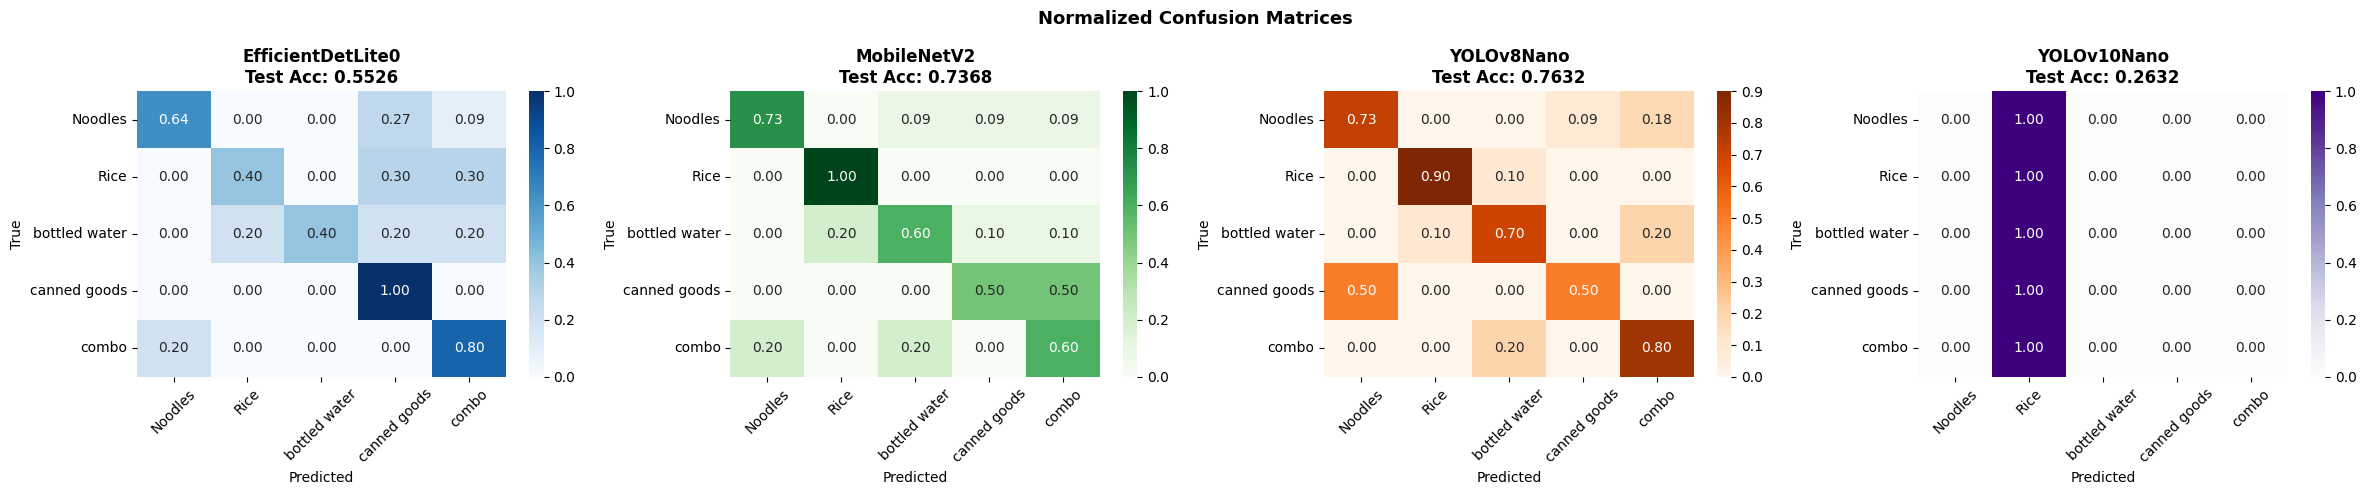

Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab07_model_replacement\outputs\figures\lab07_confusion_matrix.png


In [13]:
# Cell 11 - Confusion matrices
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(DEVICE))
            all_preds.extend(out.max(1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (mdl, name, cmap) in zip(
    axes,
    [
        (model_a, "EfficientDetLite0", "Blues"),
        (model_b, "MobileNetV2", "Greens"),
        (model_c, "YOLOv8Nano", "Oranges"),
        (model_d, "YOLOv10Nano", "Purples"),
    ],
):
    y_true, y_pred = get_predictions(mdl, test_loader)
    cm = confusion_matrix(y_true, y_pred).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap=cmap,
    )
    acc = (y_true == y_pred).mean()
    ax.set_title(f"{name}\nTest Acc: {acc:.4f}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Normalized Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_confusion_matrix.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab07_confusion_matrix.png")


## Part G) Compare Models and Summarize Results

In [14]:
# Cell 12 - Summary comparison table
rows = []
for mdl, name, hist in [
    (model_a, "EfficientDetLite0", history_a),
    (model_b, "MobileNetV2", history_b),
    (model_c, "YOLOv8Nano", history_c),
    (model_d, "YOLOv10Nano", history_d),
]:
    y_true, y_pred = get_predictions(mdl, test_loader)
    acc = (y_true == y_pred).mean()
    params = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    best_val = max(hist["val_acc"])
    rows.append(
        {
            "Model": name,
            "Parameters": f"{params:,}",
            "Best Val Acc": f"{best_val:.4f}",
            "Test Accuracy": f"{acc:.4f}",
        }
    )

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(TABLES_DIR / "lab07_model_comparison.csv", index=False)
print("Saved:", TABLES_DIR / "lab07_model_comparison.csv")


            Model Parameters Best Val Acc Test Accuracy
EfficientDetLite0  3,377,413       0.4595        0.5526
      MobileNetV2  2,230,277       0.8919        0.7368
       YOLOv8Nano  3,011,807       0.7838        0.7632
      YOLOv10Nano  2,708,974       0.2432        0.2632
Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab07_model_replacement\outputs\tables\lab07_model_comparison.csv
